## Iris Flower Classification with Decision Tree - Supervised Learning

> Tugas ini bertujuan untuk membangun model klasifikasi bunga Iris berdasarkan fitur - fitur fisik yang ada pada bunga Iris. Dataset sudah tersedia di Scikit Learn Datasets dan bisa diimpor langsung lewat ```sklearn.datasets```

> Referensi : https://colab.research.google.com/drive/1ZcRJnyah-XppyYf9B7JWrEtsVHJCZ5y_?usp=sharing


### 1. Import module yang diperlukan


In [1]:
# TODO: Import all required libraries
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.datasets import load_iris # Dataset bunga iris
from sklearn.model_selection import train_test_split
from sklearn.tree import DecisionTreeClassifier, plot_tree
from sklearn.metrics import accuracy_score, confusion_matrix, classification_report


In [2]:
# Additional utilities for deeper analysis without changing the starter workflow.
import warnings
from IPython.display import display
from sklearn.model_selection import cross_val_score
from sklearn.tree import export_text

sns.set_theme(style="whitegrid", palette="deep")
warnings.filterwarnings("ignore", message="X does not have valid feature names")


### 2. Data collection


In [3]:
iris = load_iris()
df = pd.DataFrame(iris.data, columns=iris.feature_names)
df['target'] = iris.target

# Optional: map target to actual class names
df['species'] = df['target'].map(dict(enumerate(iris.target_names)))
df.head()


,sepal length (cm),sepal width (cm),petal length (cm),petal width (cm),target,species
0,5.1,3.5,1.4,0.2,0,setosa
1,4.9,3.0,1.4,0.2,0,setosa
2,4.7,3.2,1.3,0.2,0,setosa
3,4.6,3.1,1.5,0.2,0,setosa
4,5.0,3.6,1.4,0.2,0,setosa


### TODO #1 : 
> Isi insight, coba cari tahu apa itu "sepal length, sepal width, petal length, petal width" pada bunga iris.

**Insight:** At first, the feature names can feel abstract because they are biological measurements. The sepal is the outer leaf-like part of the flower that protects the bud before it opens, while the petal is the colored inner part of the flower. Therefore, `sepal length` and `sepal width` measure the outer structure, while `petal length` and `petal width` measure the flower petals. For this classification problem, I expect petal measurements to be more informative because different Iris species often have clearer differences in petal size than in sepal size.


In [4]:
# Additional data understanding before modeling.
print(f"Dataset shape: {df.shape[0]} rows and {df.shape[1]} columns")
print(f"Feature columns: {list(iris.feature_names)}")
print(f"Target classes: {dict(enumerate(iris.target_names))}")

print("\nDataset information:")
df.info()

print("\nMissing values per column:")
display(df.isna().sum().to_frame("missing_count"))

duplicate_count = df.duplicated().sum()
print(f"Exact duplicate rows: {duplicate_count}")

if duplicate_count > 0:
    display(df[df.duplicated(keep=False)].sort_values(iris.feature_names).reset_index())

print("\nClass distribution:")
class_distribution = (
    df['species']
    .value_counts()
    .rename_axis('species')
    .reset_index(name='count')
    .assign(percentage=lambda data: (data['count'] / len(df) * 100).round(2))
)
display(class_distribution)

print("\nDescriptive statistics:")
display(df[iris.feature_names].describe().T)


Dataset shape: 150 rows and 6 columns
Feature columns: ['sepal length (cm)', 'sepal width (cm)', 'petal length (cm)', 'petal width (cm)']
Target classes: {0: 'setosa', 1: 'versicolor', 2: 'virginica'}

Dataset information:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 150 entries, 0 to 149
Data columns (total 6 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   sepal length (cm)  150 non-null    float64
 1   sepal width (cm)   150 non-null    float64
 2   petal length (cm)  150 non-null    float64
 3   petal width (cm)   150 non-null    float64
 4   target             150 non-null    int32  
 5   species            150 non-null    object 
dtypes: float64(4), int32(1), object(1)
memory usage: 6.6+ KB

Missing values per column:
Exact duplicate rows: 1

Class distribution:

Descriptive statistics:


,missing_count
sepal length (cm),0
sepal width (cm),0
petal length (cm),0
petal width (cm),0
target,0
species,0


,index,sepal length (cm),sepal width (cm),petal length (cm),petal width (cm),target,species
0,101,5.8,2.7,5.1,1.9,2,virginica
1,142,5.8,2.7,5.1,1.9,2,virginica


,species,count,percentage
0,setosa,50,33.33
1,versicolor,50,33.33
2,virginica,50,33.33


,count,mean,std,min,25%,50%,75%,max
sepal length (cm),150.0,5.843333,0.828066,4.3,5.1,5.80,6.4,7.9
sepal width (cm),150.0,3.057333,0.435866,2.0,2.8,3.00,3.3,4.4
petal length (cm),150.0,3.758000,1.765298,1.0,1.6,4.35,5.1,6.9
petal width (cm),150.0,1.199333,0.762238,0.1,0.3,1.30,1.8,2.5


**Data Understanding Note:** The dataset is small but clean: it has 150 rows, no missing values, and a balanced target distribution with 50 samples per species. There is one exact duplicate in the canonical Iris dataset. I keep it because it can reasonably represent repeated measurements with identical values, and removing one row from a standard educational dataset would not materially improve the analysis. This check is still useful because it shows that I am not assuming the dataset is clean without verification.


### 3. Exploratory Data Analysis


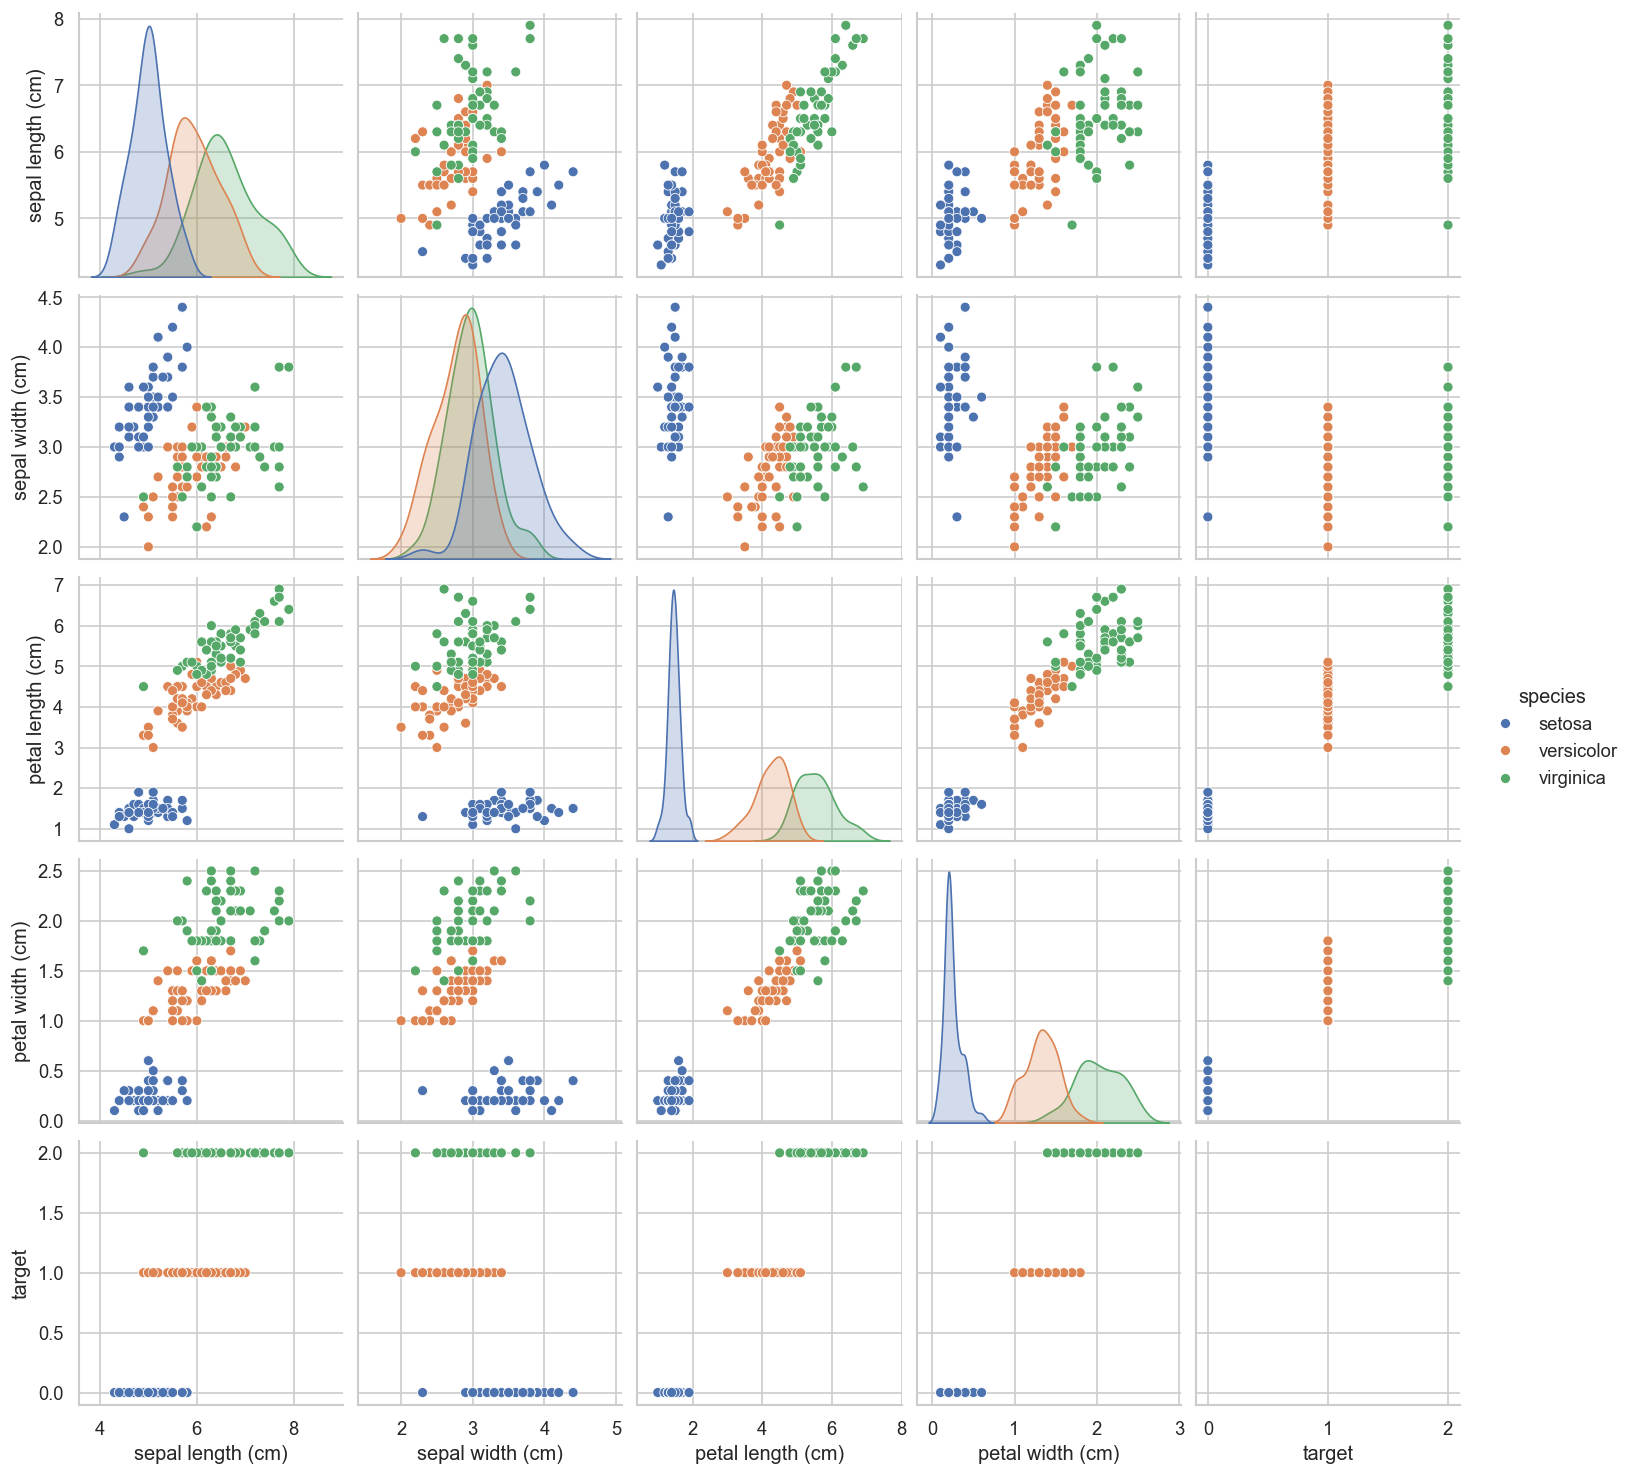

In [5]:
# TODO: Plot distribution
sns.pairplot(df, hue="species")
plt.show()


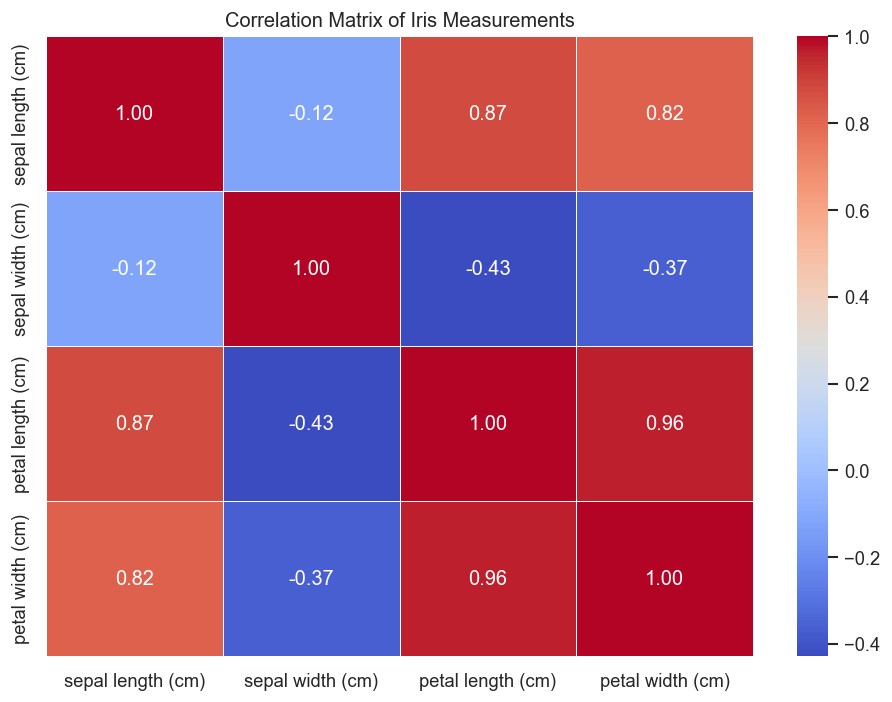

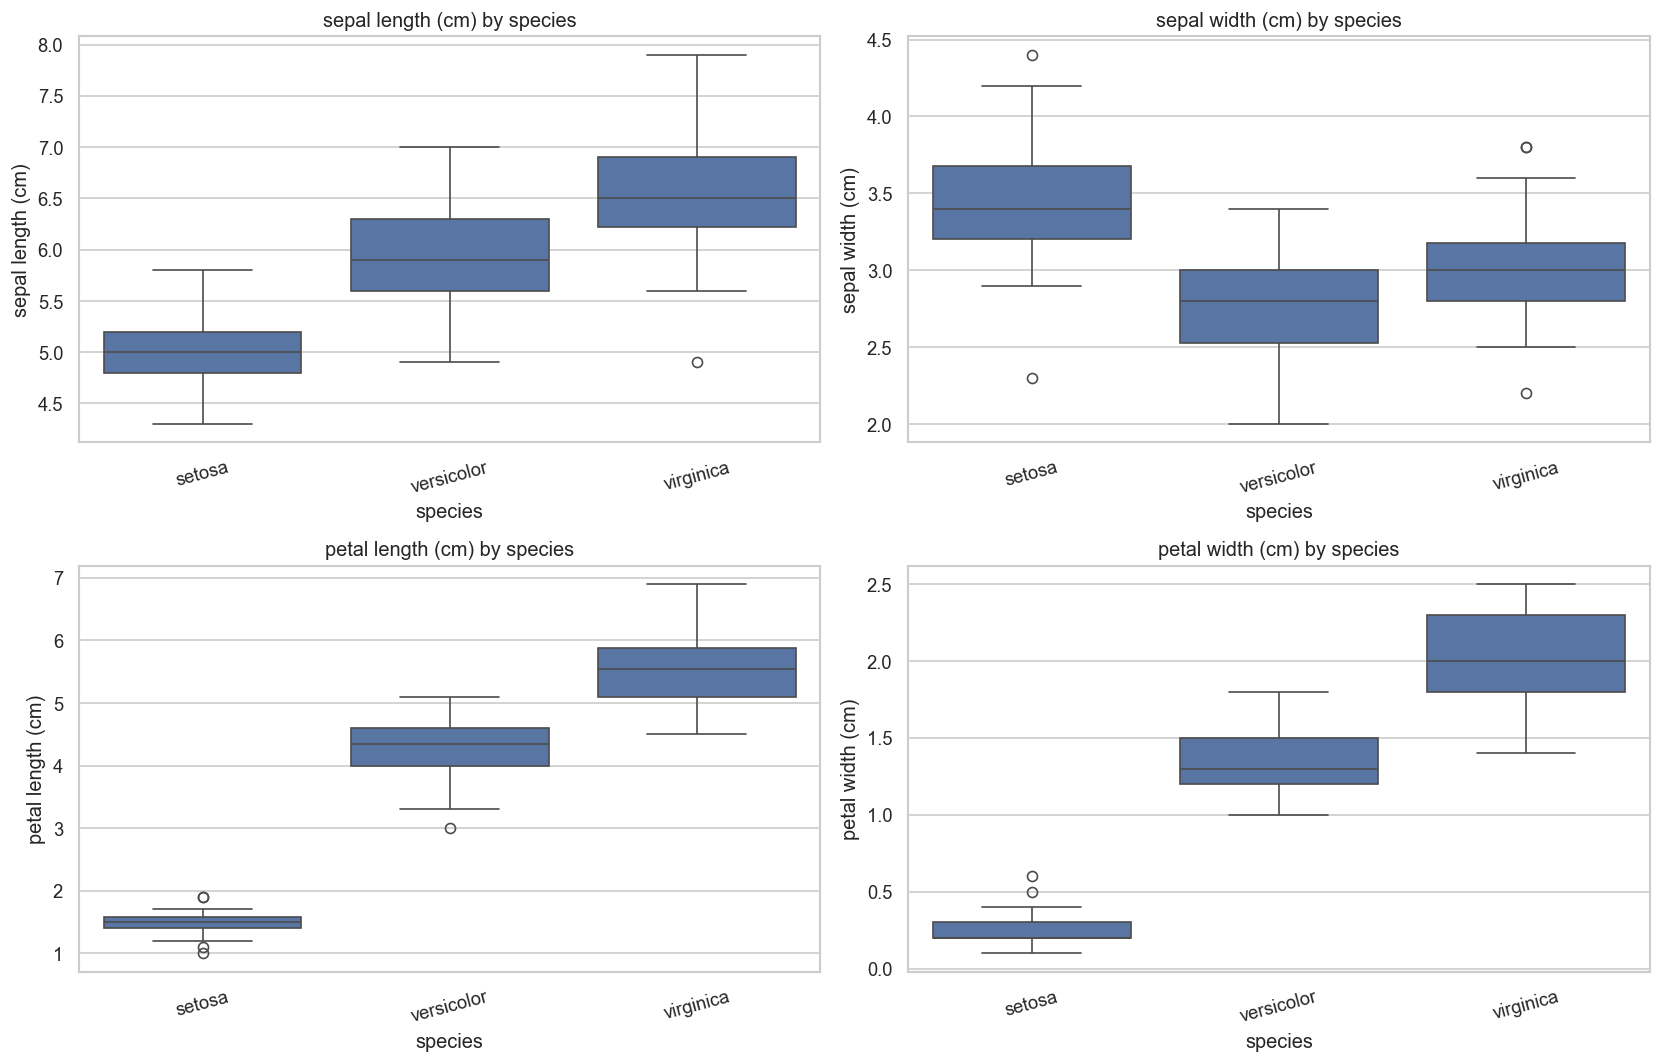

In [6]:
# Additional EDA to understand why the model can separate the species.
plt.figure(figsize=(8, 6))
sns.heatmap(df[iris.feature_names].corr(), annot=True, cmap="coolwarm", fmt=".2f", linewidths=0.5)
plt.title("Correlation Matrix of Iris Measurements")
plt.tight_layout()
plt.show()

fig, axes = plt.subplots(2, 2, figsize=(14, 9))
for axis, feature in zip(axes.flatten(), iris.feature_names):
    sns.boxplot(data=df, x="species", y=feature, ax=axis)
    axis.set_title(f"{feature} by species")
    axis.tick_params(axis="x", rotation=15)

plt.tight_layout()
plt.show()


**EDA Insight:** The pairplot makes the learning process clearer: `setosa` is visually separated from the other two species, especially by petal length and petal width. `versicolor` and `virginica` overlap more, so I expect most classification mistakes, if any, to happen between those two classes. The boxplots support the same conclusion: petal measurements show stronger species separation than sepal measurements. This is an important reason why a Decision Tree can work well here: it can split the data using simple threshold rules on petal measurements.


### 4. Split Data 


In [7]:
# TODO: Split data into training and testing
X = df[iris.feature_names]
y = df['target']

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)


In [8]:
# Additional check: verify the split size and class distribution.
split_summary = pd.DataFrame(
    {
        "Dataset": ["Training", "Testing"],
        "Rows": [X_train.shape[0], X_test.shape[0]],
        "Features": [X_train.shape[1], X_test.shape[1]],
    }
)
display(split_summary)

print("Training class distribution:")
display(pd.Series(y_train).map(dict(enumerate(iris.target_names))).value_counts().sort_index().to_frame("count"))

print("Testing class distribution:")
display(pd.Series(y_test).map(dict(enumerate(iris.target_names))).value_counts().sort_index().to_frame("count"))


Training class distribution:
Testing class distribution:


,Dataset,Rows,Features
0,Training,120,4
1,Testing,30,4


,count
target,
setosa,40
versicolor,41
virginica,39


,count
target,
setosa,10
versicolor,9
virginica,11


### 5. Model Initialization


In [9]:
# TODO: Initialize Decision Tree Classifier
model = DecisionTreeClassifier(random_state=42)


### 6. Model Training


In [10]:
# TODO: Train the model using training data
model.fit(X_train, y_train)


DecisionTreeClassifier(random_state=42)

### TODO #2 : 
> Isi insight, kenapa menggunakan Decision Tree? Apakah ada algoritma lain yang serupa?

**Insight:** A Decision Tree is a good beginner-friendly model for this task because it is easy to interpret. Instead of only producing a prediction, it also shows the decision path, such as checking whether petal length or petal width is below a certain threshold. This helps me connect the EDA findings with the model logic. Similar algorithms include Random Forest, Extra Trees, and Gradient Boosting. Those models are often stronger because they combine many trees, but a single Decision Tree is more suitable here because the assignment focuses on understanding how one tree makes classification decisions.


In [11]:
# Additional training diagnostics.
train_accuracy = accuracy_score(y_train, model.predict(X_train))
cv_scores = cross_val_score(model, X, y, cv=5, scoring="accuracy")

print(f"Training accuracy: {train_accuracy:.4f}")
print(f"Tree depth: {model.get_depth()}")
print(f"Number of leaf nodes: {model.get_n_leaves()}")
print(f"5-fold cross-validation scores: {np.round(cv_scores, 4)}")
print(f"Mean cross-validation accuracy: {cv_scores.mean():.4f}")


Training accuracy: 1.0000
Tree depth: 6
Number of leaf nodes: 10
5-fold cross-validation scores: [0.9667 0.9667 0.9    0.9333 1.    ]
Mean cross-validation accuracy: 0.9533


### 7. Evaluation


In [12]:
# TODO: Evaluate model performance
y_pred = model.predict(X_test)

print("Accuracy:", accuracy_score(y_test, y_pred))
print("\nConfusion Matrix:\n", confusion_matrix(y_test, y_pred))
print("\nClassification Report:\n", classification_report(y_test, y_pred))


Accuracy: 1.0

Confusion Matrix:
 [[10  0  0]
 [ 0  9  0]
 [ 0  0 11]]

Classification Report:
               precision    recall  f1-score   support

           0       1.00      1.00      1.00        10
           1       1.00      1.00      1.00         9
           2       1.00      1.00      1.00        11

    accuracy                           1.00        30
   macro avg       1.00      1.00      1.00        30
weighted avg       1.00      1.00      1.00        30



,setosa,versicolor,virginica
setosa,10,0,0
versicolor,0,9,0
virginica,0,0,11


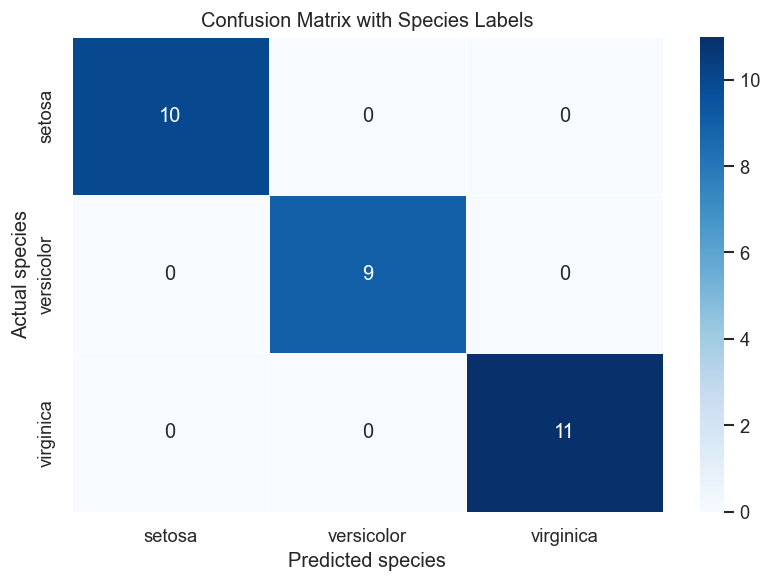

,Model,Train Accuracy,Test Accuracy,Tree Depth,Leaves,Mean CV Accuracy
0,Starter Decision Tree,1.000000,1.0,6,10,0.953333
1,Depth-Limited Tree (analysis only),0.958333,1.0,3,5,0.973333


In [13]:
# Additional evaluation with labels and a simple overfitting comparison.
conf_matrix = confusion_matrix(y_test, y_pred, labels=[0, 1, 2])
conf_matrix_df = pd.DataFrame(conf_matrix, index=iris.target_names, columns=iris.target_names)
display(conf_matrix_df)

plt.figure(figsize=(7, 5))
sns.heatmap(conf_matrix_df, annot=True, cmap="Blues", fmt="d", linewidths=0.5)
plt.xlabel("Predicted species")
plt.ylabel("Actual species")
plt.title("Confusion Matrix with Species Labels")
plt.tight_layout()
plt.show()

depth_limited_model = DecisionTreeClassifier(max_depth=3, random_state=42)
depth_limited_model.fit(X_train, y_train)

comparison = pd.DataFrame(
    [
        {
            "Model": "Starter Decision Tree",
            "Train Accuracy": accuracy_score(y_train, model.predict(X_train)),
            "Test Accuracy": accuracy_score(y_test, y_pred),
            "Tree Depth": model.get_depth(),
            "Leaves": model.get_n_leaves(),
            "Mean CV Accuracy": cv_scores.mean(),
        },
        {
            "Model": "Depth-Limited Tree (analysis only)",
            "Train Accuracy": accuracy_score(y_train, depth_limited_model.predict(X_train)),
            "Test Accuracy": accuracy_score(y_test, depth_limited_model.predict(X_test)),
            "Tree Depth": depth_limited_model.get_depth(),
            "Leaves": depth_limited_model.get_n_leaves(),
            "Mean CV Accuracy": cross_val_score(depth_limited_model, X, y, cv=5, scoring="accuracy").mean(),
        },
    ]
)
display(comparison)


### TODO #3 : 
> Isi insight, analisis hasil *confusion matrix* ini, apakah ini disebut sebagai overfitting?

**Insight:** The confusion matrix shows that the starter Decision Tree classified every test sample correctly in this split. That means there are no false predictions in the 30 test rows. However, I should not immediately conclude that the model is perfect in general, because the Iris dataset is small and relatively easy. The training accuracy is also perfect, and the tree grows deeper than the simplified comparison model. This can be a warning sign for possible overfitting, but the test accuracy and cross-validation score are still strong. So, based on this result, I would say the model is not clearly overfitting on the current split, but a depth-limited tree may be safer if the goal is simplicity and generalization.


### 8. Visualization


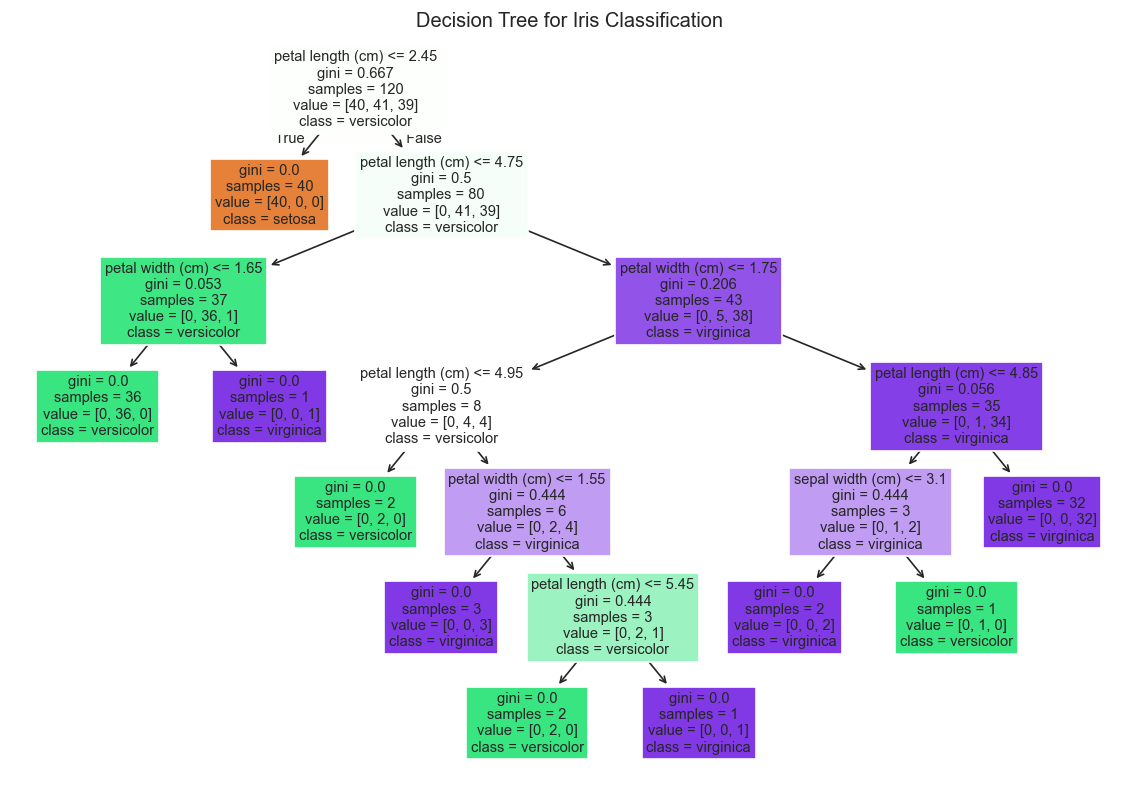

In [14]:
# TODO: Visualize the Decision Tree
plt.figure(figsize=(12,8))
plot_tree(model, feature_names=iris.feature_names, class_names=iris.target_names, filled=True)
plt.title("Decision Tree for Iris Classification")
plt.show()


In [15]:
# Additional interpretation in text form.
print("Decision rules learned by the tree:")
print(export_text(model, feature_names=list(iris.feature_names)))

feature_importance = (
    pd.DataFrame(
        {
            "Feature": iris.feature_names,
            "Importance": model.feature_importances_,
        }
    )
    .sort_values("Importance", ascending=False)
    .reset_index(drop=True)
)
display(feature_importance)


Decision rules learned by the tree:
|--- petal length (cm) <= 2.45
|   |--- class: 0
|--- petal length (cm) >  2.45
|   |--- petal length (cm) <= 4.75
|   |   |--- petal width (cm) <= 1.65
|   |   |   |--- class: 1
|   |   |--- petal width (cm) >  1.65
|   |   |   |--- class: 2
|   |--- petal length (cm) >  4.75
|   |   |--- petal width (cm) <= 1.75
|   |   |   |--- petal length (cm) <= 4.95
|   |   |   |   |--- class: 1
|   |   |   |--- petal length (cm) >  4.95
|   |   |   |   |--- petal width (cm) <= 1.55
|   |   |   |   |   |--- class: 2
|   |   |   |   |--- petal width (cm) >  1.55
|   |   |   |   |   |--- petal length (cm) <= 5.45
|   |   |   |   |   |   |--- class: 1
|   |   |   |   |   |--- petal length (cm) >  5.45
|   |   |   |   |   |   |--- class: 2
|   |   |--- petal width (cm) >  1.75
|   |   |   |--- petal length (cm) <= 4.85
|   |   |   |   |--- sepal width (cm) <= 3.10
|   |   |   |   |   |--- class: 2
|   |   |   |   |--- sepal width (cm) >  3.10
|   |   |   |   |   |

,Feature,Importance
0,petal length (cm),0.906143
1,petal width (cm),0.077186
2,sepal width (cm),0.016670
3,sepal length (cm),0.000000


### TODO #4 : 
> Isi insight, berikan penjelasan cara kerja dari Decision Tree berdasarkan output diatas.

**Insight:** The tree starts from a root node and asks yes/no questions based on feature thresholds. In this model, the most important splits are based on petal measurements. A simple example is: if petal length is very small, the flower is classified as `setosa`. If the petal is larger, the tree checks additional thresholds to separate `versicolor` and `virginica`. Each branch represents the answer to a condition, and each leaf node is the final class prediction. This visualization helps me understand that the model is not guessing randomly; it is building a sequence of measurement-based rules.


### 9. Prediction


In [16]:
# predict new data
def predict_iris(sample):
    pred_class = model.predict([sample])[0]
    return iris.target_names[pred_class]

# Example:
example = [5.1, 3.5, 1.4, 0.2] # "sepal length, sepal width, petal length, petal width"
print("Predicted class:", predict_iris(example))


Predicted class: setosa


In [17]:
# Additional prediction trials using several realistic examples.
manual_samples = pd.DataFrame(
    [
        [5.1, 3.5, 1.4, 0.2],
        [6.0, 2.9, 4.5, 1.5],
        [6.7, 3.0, 5.2, 2.3],
        [6.0, 2.7, 5.0, 1.6],
    ],
    columns=iris.feature_names,
    index=[
        "Setosa-like sample",
        "Versicolor-like sample",
        "Virginica-like sample",
        "Borderline versicolor-virginica sample",
    ],
)

manual_predictions = model.predict(manual_samples)
manual_probabilities = model.predict_proba(manual_samples)

prediction_results = manual_samples.copy()
prediction_results["Predicted species"] = [iris.target_names[class_id] for class_id in manual_predictions]
prediction_results["Highest class probability"] = manual_probabilities.max(axis=1).round(3)

display(prediction_results)


,sepal length (cm),sepal width (cm),petal length (cm),petal width (cm),Predicted species,Highest class probability
Setosa-like sample,5.1,3.5,1.4,0.2,setosa,1.0
Versicolor-like sample,6.0,2.9,4.5,1.5,versicolor,1.0
Virginica-like sample,6.7,3.0,5.2,2.3,virginica,1.0
Borderline versicolor-virginica sample,6.0,2.7,5.0,1.6,versicolor,1.0


### TODO #5 : 
> Isi insight, berikan beberapa kali percobaan untuk mengklasifikasikan beberapa spesies bunga Iris berbeda berdasarkan "sepal length, sepal width, petal length, petal width".

**Insight:** I tested several manual inputs to understand how the model reacts to different flower measurements. The small-petal sample is predicted as `setosa`, which matches the EDA pattern. The medium-petal sample is predicted as `versicolor`, while the larger-petal sample is predicted as `virginica`. I also included a borderline sample because `versicolor` and `virginica` are the two species that are visually closer in the EDA. These trials make the model behavior easier to understand: the prediction changes mainly when petal length and petal width move from small, to medium, to large values.
